<a href="https://colab.research.google.com/github/Jahnavi-711/DL-Lab-Work/blob/main/DL_EXP_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [2]:
(X_train, _), (X_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

In [4]:
X_train = X_train.reshape((len(X_train), 784))
X_test = X_test.reshape((len(X_test), 784))

In [5]:
input_dim = 784
encoding_dim = 32

input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
encoded_output = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(64, activation='relu')(encoded_output)
decoded = Dense(128, activation='relu')(decoded)
decoded_output = Dense(input_dim, activation='sigmoid')(decoded)

# Autoencoder Model
autoencoder = Model(input_layer, decoded_output)

In [6]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [7]:
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.2555 - val_loss: 0.1722
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1528 - val_loss: 0.1377
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1327 - val_loss: 0.1263
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1239 - val_loss: 0.1191
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.1181 - val_loss: 0.1145
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1140 - val_loss: 0.1116
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1109 - val_loss: 0.1082
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1085 - val_loss: 0.1061
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1064 - val_loss: 0.1041
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1045 - val_loss: 0.1024
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1030 - val_loss: 0.1012
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

In [8]:
decoded_imgs = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


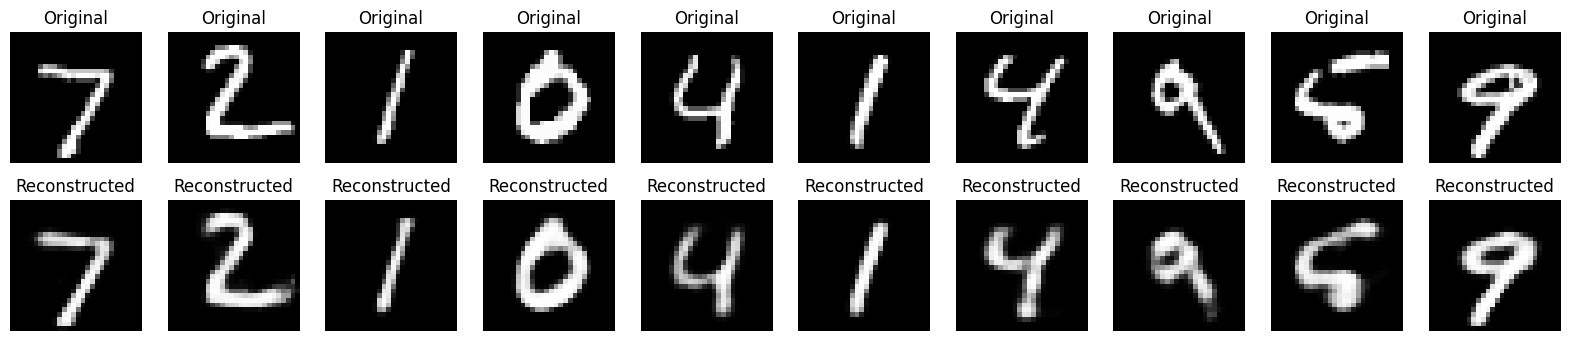

In [9]:
n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # Original Image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed Image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

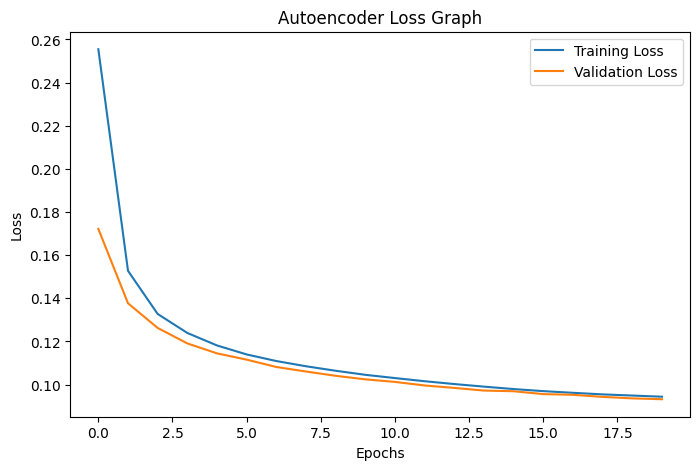

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Autoencoder Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()